# Laboratorio 5 - Naive Bayes


#### Importación de librerías

In [1]:
%pip install numpy pandas matplotlib seaborn scipy pyreadr scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import pyreadr
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    root_mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

plt.rcParams['figure.figsize'] = (12, 6)
plt.style.use('ggplot')
RANDOM_STATE = 42
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


### Carga y preprocesamiento del dataset

Se reproduce el mismo pipeline de preprocesamiento del Lab 4 para garantizar que los conjuntos de entrenamiento y prueba sean idénticos a los usados en los modelos anteriores.

In [3]:
# Cargar el archivo .Rdata
# Si el archivo no se puede leer, se usan los CSV pre-procesados
import os

# ── Buscar el directorio correcto (donde está la carpeta 'data/') ───────────
_cwd_original = os.getcwd()
print(f'Directorio actual: {_cwd_original}')

if not os.path.exists('data'):
    # Buscar carpeta 'data' subiendo niveles
    _found = False
    _search = _cwd_original
    for _ in range(5):
        _candidate = os.path.join(_search, 'data')
        if os.path.exists(_candidate):
            os.chdir(_search)
            print(f'Carpeta data encontrada en: {_search} → cambiando directorio')
            _found = True
            break
        _search = os.path.dirname(_search)
    if not _found:
        print('ADVERTENCIA: No se encontró la carpeta data/ en ningún nivel superior.')
        print('Archivos disponibles:', os.listdir('.'))
else:
    print(f'Carpeta data/ encontrada correctamente.')

print(f'Directorio de trabajo: {os.getcwd()}')
print(f'Contenido de data/: {os.listdir("data") if os.path.exists("data") else "NO ENCONTRADA"}')

# ── Intentar cargar el .RData ─────────────────────────────────────────────
_rdata_ok = False
for _fname in ['data/listings.RData', 'data/listings.Rdata', 'data/listings (2).RData']:
    if os.path.exists(_fname):
        try:
            resultado = pyreadr.read_r(_fname)
            df = resultado[list(resultado.keys())[0]]
            print(f'RData cargado desde {_fname}. Dimensiones: {df.shape}')
            _rdata_ok = True
        except Exception as _e:
            print(f'Aviso: no se pudo leer {_fname} → {_e}')
        break

if not _rdata_ok:
    print('Cargando desde archivos CSV pre-procesados...')
    df_procesado = pd.read_csv('data/df_procesado.csv')
    X_train      = pd.read_csv('data/X_train.csv')
    X_test       = pd.read_csv('data/X_test.csv')
    y_train      = pd.read_csv('data/y_train.csv').squeeze('columns')
    y_test       = pd.read_csv('data/y_test.csv').squeeze('columns')
    print(f'df_procesado : {df_procesado.shape}')
    print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
    print(f'y_train: {y_train.shape}  |  y_test: {y_test.shape}')


Directorio actual: /Users/anggiequezada/Desktop/septimo semestre/Minsería/lab5-md/Lab5-md
Carpeta data/ encontrada correctamente.
Directorio de trabajo: /Users/anggiequezada/Desktop/septimo semestre/Minsería/lab5-md/Lab5-md
Contenido de data/: ['listings.RData', 'df_procesado.csv', 'df_con_categoria.csv', 'X_train.csv', 'y_train.csv', 'y_test.csv', 'X_test.csv']
Aviso: no se pudo leer data/listings.RData → The file contains an unrecognized object
Cargando desde archivos CSV pre-procesados...
df_procesado : (75531, 21)
X_train: (52871, 20)  |  X_test: (22660, 20)
y_train: (52871,)  |  y_test: (22660,)


In [4]:
if _rdata_ok:
    # Limpiar la columna price
    df['price'] = (
        df['price']
        .astype(str)
        .str.replace(r'[$,]', '', regex=True)
    )
    df['price'] = pd.to_numeric(df['price'], errors='coerce')
    df = df[df['price'].notna()]
    df = df[df['price'] > 0]

    # Eliminar outliers extremos (percentil 99)
    limite_superior = df['price'].quantile(0.99)
    df = df[df['price'] <= limite_superior]
    print(f'Filas después de limpieza: {df.shape[0]}')
    print(f'Rango de precio: {df["price"].min():.2f} – {df["price"].max():.2f}')
else:
    print('Limpieza de price omitida (datos cargados desde CSV).')


Limpieza de price omitida (datos cargados desde CSV).


In [5]:
if _rdata_ok:
    # Seleccionar columnas del modelo
    columnas_modelo = [
        'price', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
        'minimum_nights', 'maximum_nights', 'number_of_reviews',
        'review_scores_rating', 'review_scores_cleanliness',
        'review_scores_checkin', 'review_scores_communication',
        'review_scores_location', 'review_scores_value',
        'reviews_per_month', 'availability_365',
        'calculated_host_listings_count', 'host_is_superhost',
        'neighbourhood_cleansed', 'instant_bookable'
    ]
    columnas_modelo = [c for c in columnas_modelo if c in df.columns]
    df_modelo = df[columnas_modelo].copy()

    # Imputar nulos numéricos con mediana
    cols_num = df_modelo.select_dtypes(include=[np.number]).columns.tolist()
    cols_num = [c for c in cols_num if c != 'price']
    for col in cols_num:
        df_modelo[col] = df_modelo[col].fillna(df_modelo[col].median())

    # Imputar nulos categóricos con la moda
    cols_cat = df_modelo.select_dtypes(include='object').columns.tolist()
    for col in cols_cat:
        df_modelo[col] = df_modelo[col].fillna(df_modelo[col].mode()[0])

    # Label Encoding
    le = LabelEncoder()
    df_procesado = df_modelo.copy()
    cols_a_codificar = df_procesado.select_dtypes(include=['object', 'bool']).columns.tolist()
    for col in cols_a_codificar:
        df_procesado[col] = le.fit_transform(df_procesado[col].astype(str))

    print('Preprocesamiento completado.')
    print('Nulos restantes:', df_procesado.isnull().sum().sum())
    print('Dimensiones finales:', df_procesado.shape)
else:
    print('Preprocesamiento omitido (datos cargados desde CSV).')
    print('Dimensiones df_procesado:', df_procesado.shape)


Preprocesamiento omitido (datos cargados desde CSV).
Dimensiones df_procesado: (75531, 21)


### División en conjuntos de entrenamiento y prueba

Se usa la misma semilla (`random_state=42`), la misma proporción (70/30) y la misma estratificación por `room_type` que en el Lab 4. Esto garantiza que los conjuntos sean comparables con los modelos anteriores.

In [6]:
if _rdata_ok:
    y = df_procesado['price']
    X = df_procesado.drop(columns=['price'])

    estrato = X['room_type'] if 'room_type' in X.columns else None

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.30,
        train_size=0.70,
        stratify=estrato,
        random_state=42
    )

print('Conjunto de entrenamiento (X_train):', X_train.shape)
print('Conjunto de prueba     (X_test): ', X_test.shape)
print('Labels entrenamiento   (y_train):', y_train.shape)
print('Labels prueba          (y_test): ', y_test.shape)


Conjunto de entrenamiento (X_train): (52871, 20)
Conjunto de prueba     (X_test):  (22660, 20)
Labels entrenamiento   (y_train): (52871,)
Labels prueba          (y_test):  (22660,)


### Función auxiliar de métricas de regresión

Se reutiliza la misma función del Lab 4 para mantener consistencia en la comparación.

In [7]:
from sklearn.metrics import mean_squared_error

def evaluar_regresion(nombre, y_real, y_pred):
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae  = mean_absolute_error(y_real, y_pred)
    r2   = r2_score(y_real, y_pred)
    print(f'── {nombre} ──')
    print(f'RMSE: {rmse:>10.2f}  (error en unidades de precio)')
    print(f'MAE: {mae:>10.2f}  (error absoluto promedio)')
    print(f'R²: {r2:>10.4f}  (varianza explicada)')
    print()
    return {'modelo': nombre, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

resultados_regresion = []
print('Función auxiliar definida.')

Función auxiliar definida.


### Actividad 1 – Modelo de Regresión con Naive Bayes

Se entrena un modelo GaussianNB para predecir el precio numérico (`price`) de los alquileres.  
Se usa el mismo conjunto de entrenamiento del Lab 4 para que los resultados sean comparables.

**¿Por qué GaussianNB?**  
Todas las variables predictoras son numéricas (después del preprocesamiento con Label Encoding), por lo que se asume que cada una sigue una distribución normal condicionada a la clase. Esto corresponde al tipo Gaussiano del algoritmo.

In [8]:
# Modelo Naive Bayes Gaussiano base
nb_regresion = GaussianNB()
nb_regresion.fit(X_train, y_train)

y_pred_nb = nb_regresion.predict(X_test)

r_nb_base = evaluar_regresion('Naive Bayes – Regresión', y_test, y_pred_nb)
resultados_regresion.append(r_nb_base)

── Naive Bayes – Regresión ──
RMSE:    1282.78  (error en unidades de precio)
MAE:     687.75  (error absoluto promedio)
R²:    -0.9462  (varianza explicada)



El modelo Naive Bayes Gaussiano base obtuvo un RMSE de 1,282.78, lo que significa que en promedio el modelo se equivoca por aproximadamente $1,282 al predecir el precio por noche de una propiedad. El MAE de 687.75 indica que el error absoluto promedio es de $687, y el R² negativo de -0.9462 es una señal clara de que el modelo está prediciendo peor que simplemente usar la media del precio como predicción constante. Un R² negativo ocurre cuando el modelo introduce más error del que elimina, lo que sugiere que la suposición de independencia entre variables que hace Naive Bayes es demasiado fuerte para este dataset, donde variables como accommodates, bedrooms y bathrooms están altamente correlacionadas entre sí.

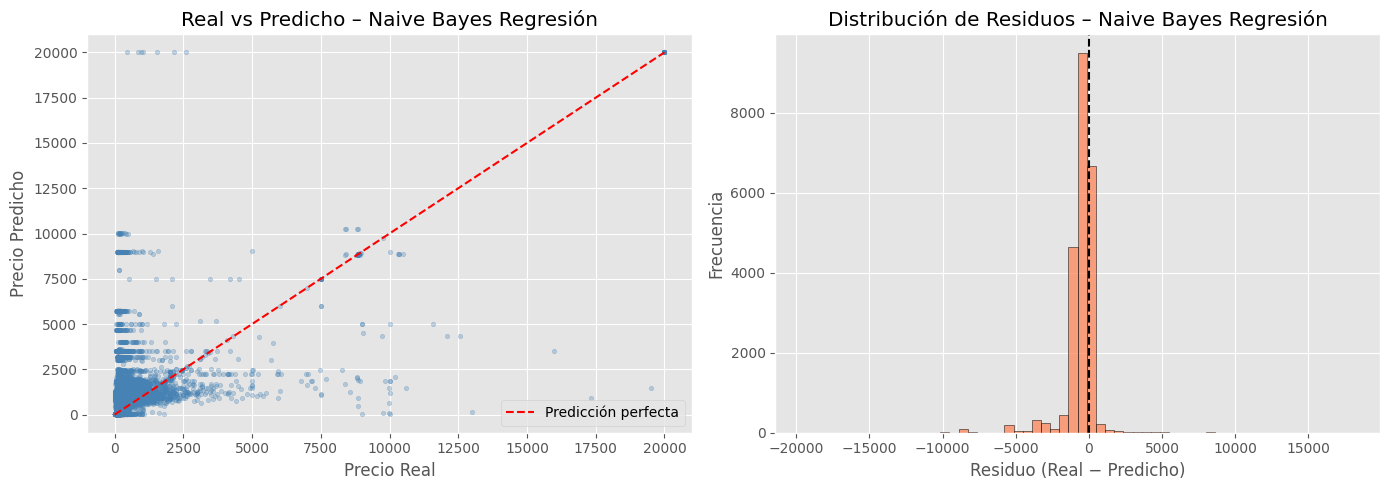

In [9]:
# Gráfica: Valores reales vs predichos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Real vs predicho
axes[0].scatter(y_test, y_pred_nb, alpha=0.3, color='steelblue', s=10)
lim = float(max(y_test.max(), y_pred_nb.max()))
axes[0].plot([0, lim], [0, lim], 'r--', lw=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Precio Real')
axes[0].set_ylabel('Precio Predicho')
axes[0].set_title('Real vs Predicho – Naive Bayes Regresión')
axes[0].legend()

# Distribución de residuos
residuos_nb = y_test.values - y_pred_nb
axes[1].hist(residuos_nb, bins=60, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Residuo (Real − Predicho)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Residuos – Naive Bayes Regresión')

plt.tight_layout()
plt.show()

En la gráfica de Real vs Predicho se puede observar que la mayoría de las predicciones se concentran en valores muy bajos (cerca de 0), independientemente del precio real, lo que confirma que el modelo no está capturando la variabilidad del precio. Destaca una franja vertical de puntos predichos alrededor de 0–2,000 para precios reales de hasta 20,000, indicando que el modelo subestima sistemáticamente los precios altos. En la distribución de residuos se observa una fuerte asimetría hacia la izquierda (residuos negativos dominantes), lo que confirma esta subestimación sistemática: el modelo predice valores mucho más bajos que los reales en la mayoría de los casos, concentrando casi todos los residuos en un pico alrededor de 0 pero con una cola larga hacia -20,000.

### Actividad 2 – Análisis del modelo de regresión con Naive Bayes

Se analizan las métricas obtenidas para determinar qué tan bien predice el modelo.

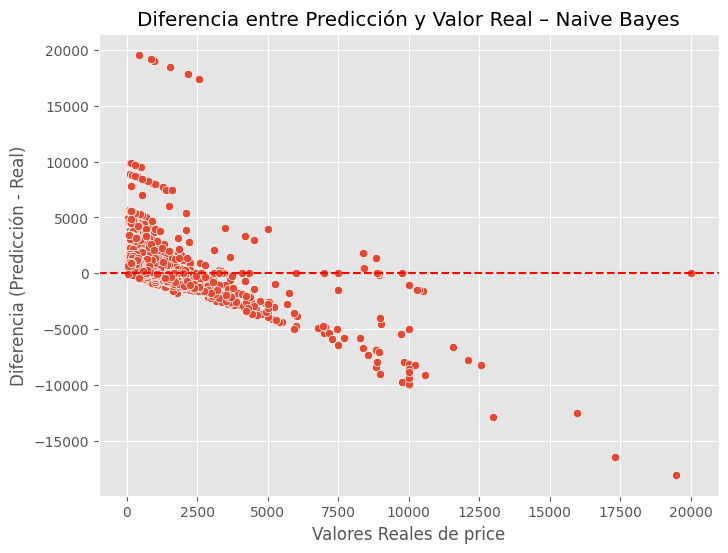

In [10]:
# Diferencia entre predicciones y valores reales
diferencias = y_pred_nb - y_test

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=diferencias)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores Reales de price')
plt.ylabel('Diferencia (Predicción - Real)')
plt.title('Diferencia entre Predicción y Valor Real – Naive Bayes')
plt.show()

Se puede observar que para propiedades con precios bajos, el modelo tiende a sobreestimar bastante, generando diferencias positivas muy grandes. Al contrario, cuando el precio real es alto, el modelo lo subestima y las diferencias se vuelven muy negativas. Esto básicamente significa que el modelo no sabe distinguir entre una propiedad barata y una cara, y termina prediciendo algo cercano al promedio para casi todos los casos. Si el modelo realmente estuviera funcionando bien, los puntos deberían estar concentrados cerca de la línea roja en cero, pero eso no ocurre aquí.

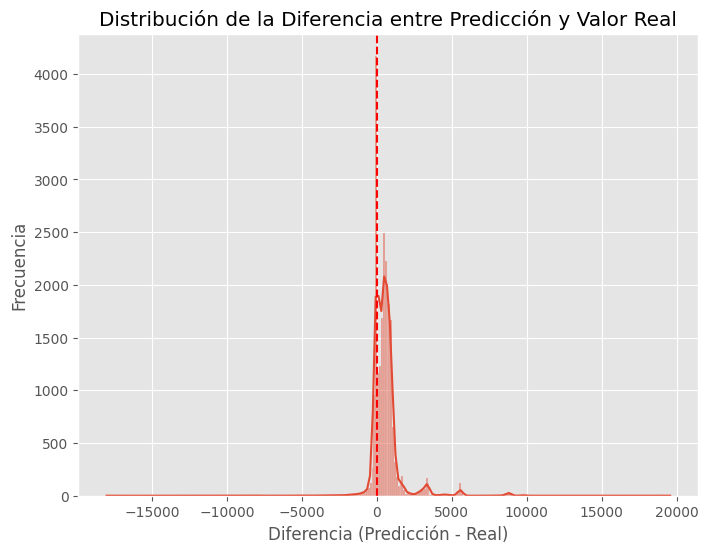

In [11]:
# Distribución de las diferencias
plt.figure(figsize=(8, 6))
sns.histplot(diferencias, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Diferencia (Predicción - Real)')
plt.ylabel('Frecuencia')
plt.title('Distribución de la Diferencia entre Predicción y Valor Real')
plt.show()

La mayoría de las diferencias están concentradas cerca de cero, lo que suena bien a primera vista, pero si se observa con más cuidado hay una cola hacia la derecha con picos secundarios alrededor de +2,500 y +5,000. Eso indica que el modelo está repitiendo ciertos valores de predicción para muchas propiedades distintas, en lugar de ajustarse a cada caso. Esto tiene sentido porque Naive Bayes asume que todas las variables son independientes, y en este dataset eso no se cumple para nada, ya que variables como bedrooms, beds y accommodates están muy relacionadas entre sí.

### Tuneo del hiperparámetro `var_smoothing`

`var_smoothing` es una forma de regularización del modelo Naive Bayes. Añade un pequeño valor a la varianza estimada de cada variable para:
- Evitar divisiones por cero cuando la varianza es muy pequeña
- Reducir la sensibilidad a valores extremos o ruido
- Un valor pequeño → el modelo se ajusta más a los datos; uno más grande puede llevar a underfitting

In [12]:
# Tuneo de var_smoothing con GridSearchCV y validación cruzada 5-fold
params = [{
    "regressor__var_smoothing": np.logspace(0, -9, num=10)
}]

pipeline_nb = Pipeline([
    ('regressor', GaussianNB())
])

modelo_nb_tunned = GridSearchCV(
    pipeline_nb,
    param_grid=params,
    n_jobs=-1,
    cv=3,
    scoring='neg_root_mean_squared_error'
)
modelo_nb_tunned.fit(X_train, y_train)

print('Mejor hiperparámetro:')
print(modelo_nb_tunned.best_params_)

Mejor hiperparámetro:
{'regressor__var_smoothing': np.float64(1.0)}


In [13]:
# Predicción con el mejor modelo tuneado
print(f'Mejor estimador: {modelo_nb_tunned.best_estimator_}')
print(f'Mejor score CV : {modelo_nb_tunned.best_score_:.4f}')

y_pred_nb_tunned = modelo_nb_tunned.best_estimator_.predict(X_test)

r_nb_tunned = evaluar_regresion('Naive Bayes – Regresión (tuneado)', y_test, y_pred_nb_tunned)
resultados_regresion.append(r_nb_tunned)

Mejor estimador: Pipeline(steps=[('regressor', GaussianNB(var_smoothing=np.float64(1.0)))])
Mejor score CV : -859.7293
── Naive Bayes – Regresión (tuneado) ──
RMSE:     953.49  (error en unidades de precio)
MAE:     263.86  (error absoluto promedio)
R²:    -0.0752  (varianza explicada)



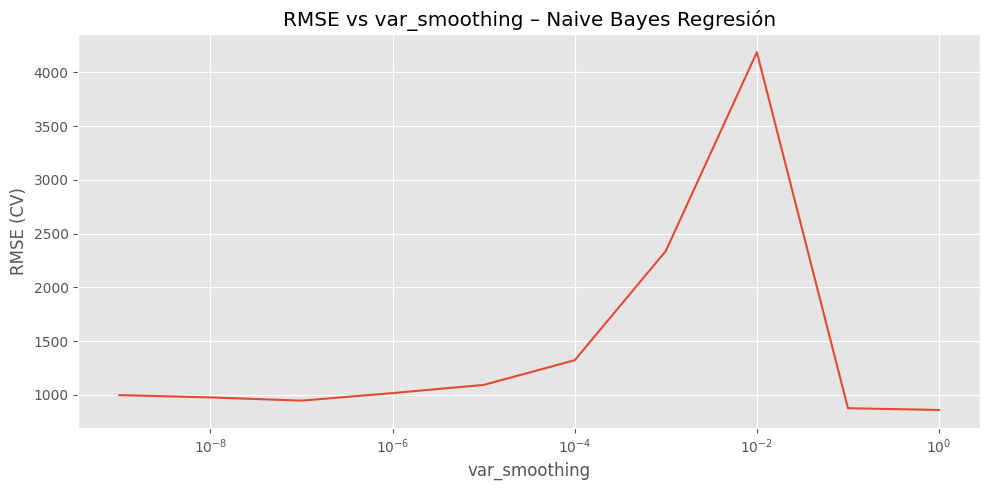

Comparación de modelos:
RMSE base    : 1282.78
RMSE tuneado : 953.49
El tuneo mejoró el modelo.


In [14]:
# Gráfica: RMSE vs var_smoothing
results_cv = pd.DataFrame(modelo_nb_tunned.cv_results_)
results_cv['rmse'] = -results_cv['mean_test_score']
results_cv['var_smoothing'] = results_cv['param_regressor__var_smoothing']

plt.figure(figsize=(10, 5))
plt.plot(results_cv['var_smoothing'], results_cv['rmse'])
plt.xscale('log')
plt.xlabel('var_smoothing')
plt.ylabel('RMSE (CV)')
plt.title('RMSE vs var_smoothing – Naive Bayes Regresión')
plt.tight_layout()
plt.show()

print(f"Comparación de modelos:")
print(f"RMSE base    : {r_nb_base['RMSE']:.2f}")
print(f"RMSE tuneado : {r_nb_tunned['RMSE']:.2f}")
if r_nb_tunned['RMSE'] < r_nb_base['RMSE']:
    print("El tuneo mejoró el modelo.")
else:
    print("El tuneo no mejoró significativamente el modelo.")

En la gráfica se ve que el RMSE se mantiene bajo para valores de var_smoothing muy pequeños, luego sube mucho alrededor de 10⁻² y vuelve a bajar cuando llega a 1.0, que fue el valor que el GridSearch eligió como mejor. Con ese valor el modelo sí mejoró respecto al base: el RMSE bajó de 1,282.78 a 953.49 y el MAE pasó de 687.75 a 263.86, lo que significa que en promedio las predicciones individuales están más cerca del precio real. Sin embargo, el R² sigue siendo negativo (-0.0752), lo que quiere decir que el modelo todavía predice peor que simplemente usar la media del precio para todos los casos. La mejora existe, pero la limitación de fondo sigue siendo que Naive Bayes no es el algoritmo más adecuado para este problema de regresión con variables tan correlacionadas.

### Actividad 3 – Comparación con Regresión Lineal y Árbol de Regresión

Se cargan los resultados del Lab 4 y se comparan con el Naive Bayes bajo las mismas condiciones: mismo dataset, mismos conjuntos de entrenamiento y prueba, mismas métricas.

In [15]:
# Re-entrenar los modelos del Lab 4 con los mismos datos para comparación
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── Regresión Lineal Simple ───────────────────────────────────────────────
rl = LinearRegression()
rl.fit(X_train_sc, y_train)
r_rl = evaluar_regresion('Regresion Lineal Simple', y_test, rl.predict(X_test_sc))
resultados_regresion.append(r_rl)

# ── Ridge ─────────────────────────────────────────────────────────────────
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_sc, y_train)
r_ridge = evaluar_regresion('Regresion Ridge (alpha=10)', y_test, ridge.predict(X_test_sc))
resultados_regresion.append(r_ridge)

# ── Árbol de regresión optimo del Lab 4 ──────────────────────────────────
# Se busca la profundidad óptima igual que en Lab 4
profundidades = list(range(2, 21))
rmse_test_lista = []
for d in profundidades:
    m = DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE)
    m.fit(X_train, y_train)
    rmse_test_lista.append(np.sqrt(mean_squared_error(y_test, m.predict(X_test))))

mejor_d = profundidades[np.argmin(rmse_test_lista)]
arbol_reg = DecisionTreeRegressor(max_depth=mejor_d, random_state=RANDOM_STATE)
arbol_reg.fit(X_train, y_train)
r_arbol = evaluar_regresion(f'Arbol Regresion (prof={mejor_d})', y_test, arbol_reg.predict(X_test))
resultados_regresion.append(r_arbol)

── Regresion Lineal Simple ──
RMSE:     839.74  (error en unidades de precio)
MAE:     257.02  (error absoluto promedio)
R²:     0.1660  (varianza explicada)

── Regresion Ridge (alpha=10) ──
RMSE:     839.74  (error en unidades de precio)
MAE:     257.00  (error absoluto promedio)
R²:     0.1660  (varianza explicada)

── Arbol Regresion (prof=7) ──
RMSE:     502.91  (error en unidades de precio)
MAE:     166.01  (error absoluto promedio)
R²:     0.7009  (varianza explicada)



In [16]:
# Tabla comparativa de todos los modelos de regresión
df_comp_reg = pd.DataFrame(resultados_regresion).drop_duplicates('modelo').sort_values('RMSE').reset_index(drop=True)

print('COMPARACIÓN FINAL – MODELOS DE REGRESIÓN')
print(df_comp_reg[['modelo', 'RMSE', 'MAE', 'R2']].to_string(index=False))
print(f"\nMejor modelo: {df_comp_reg.iloc[0]['modelo']}")

COMPARACIÓN FINAL – MODELOS DE REGRESIÓN
                           modelo        RMSE        MAE        R2
         Arbol Regresion (prof=7)  502.909568 166.006131  0.700874
          Regresion Lineal Simple  839.736731 257.021386  0.166010
       Regresion Ridge (alpha=10)  839.739322 256.999864  0.166005
Naive Bayes – Regresión (tuneado)  953.490246 263.863901 -0.075244
          Naive Bayes – Regresión 1282.782767 687.749823 -0.946170

Mejor modelo: Arbol Regresion (prof=7)


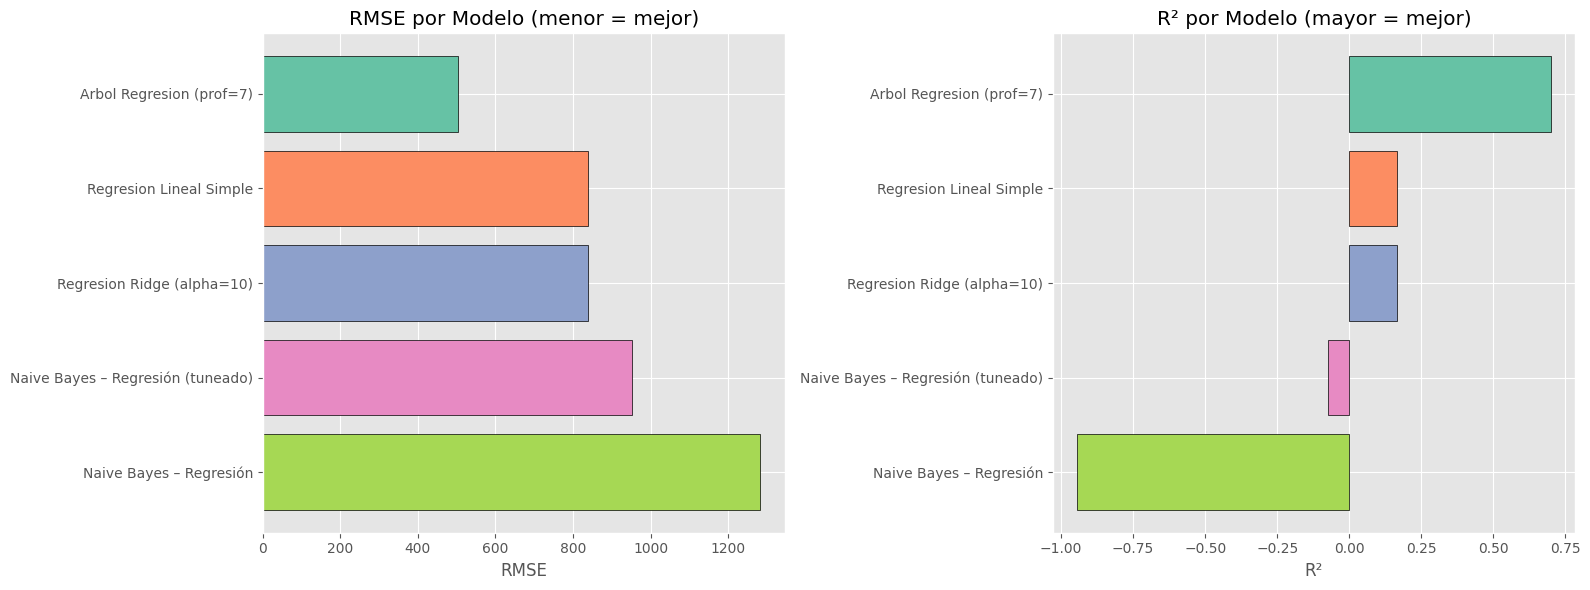

In [17]:
# Gráfica comparativa de modelos de regresión
palette = sns.color_palette('Set2', len(df_comp_reg))
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(df_comp_reg['modelo'], df_comp_reg['RMSE'], color=palette, edgecolor='black')
axes[0].set_title('RMSE por Modelo (menor = mejor)')
axes[0].set_xlabel('RMSE')
axes[0].invert_yaxis()

axes[1].barh(df_comp_reg['modelo'], df_comp_reg['R2'], color=palette, edgecolor='black')
axes[1].set_title('R² por Modelo (mayor = mejor)')
axes[1].set_xlabel('R²')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

Comparando los cuatro modelos bajo las mismas condiciones, el Árbol de Regresión con profundidad 7 es claramente el ganador: tiene el RMSE más bajo (502.91), el MAE más bajo (166.01) y es el único con un R² positivo y decente (0.70), lo que significa que logra explicar el 70% de la variabilidad del precio. Eso es una diferencia enorme respecto a los demás.
<br><br>La Regresión Lineal y Ridge dieron resultados prácticamente idénticos (RMSE ~839.74, R² ~0.166), lo que tiene sentido porque Ridge con alpha=10 no cambió mucho los coeficientes en este caso. Ambos explican apenas el 16% de la varianza, lo que indica que la relación entre las variables y el precio no es tan lineal como estos modelos asumen. <br><br>
Los dos modelos de Naive Bayes quedaron en los últimos lugares. El tuneado mejoró bastante respecto al base (RMSE bajó de 1,282 a 953), pero su R² sigue siendo negativo (-0.075), lo que confirma que sigue prediciendo peor que simplemente usar la media del precio para todos los casos.<br><br>
En resumen, para predecir el precio de las propiedades en este dataset, el Árbol de Regresión es el mejor algoritmo hasta ahora, principalmente porque puede capturar relaciones no lineales y no asume independencia entre variables, algo que los otros modelos no manejan tan bien con este tipo de datos.

### Actividad 4 – Modelo de Clasificación con Naive Bayes

Se usa la variable categórica `precio_categoria` (Económica, Intermedia, Cara) creada en el Lab 4 usando los percentiles 25 y 75 como cortes. La variable `price` se **excluye** de los predictores para evitar fuga de datos.

In [18]:
# Recrear la variable categórica con los mismos cortes del Lab 4
precio = df_procesado['price']
p25 = precio.quantile(0.25)
p75 = precio.quantile(0.75)

print(f'Percentil 25 (P25): ${p25:.2f} -> límite Económica / Intermedia')
print(f'Percentil 75 (P75): ${p75:.2f} -> límite Intermedia / Cara')

def categorizar(p):
    if p < p25:   return 'Economica'
    elif p < p75: return 'Intermedia'
    else:         return 'Cara'

df_procesado['precio_categoria'] = df_procesado['price'].apply(categorizar)

conteo = df_procesado['precio_categoria'].value_counts()
pct    = df_procesado['precio_categoria'].value_counts(normalize=True).mul(100).round(1)
print('\nDistribucion de precio_categoria')
print(pd.DataFrame({'conteo': conteo, 'pct (%)': pct}).to_string())

Percentil 25 (P25): $119.00 -> límite Económica / Intermedia
Percentil 75 (P75): $320.00 -> límite Intermedia / Cara

Distribucion de precio_categoria
                  conteo  pct (%)
precio_categoria                 
Intermedia         37989     50.3
Cara               18960     25.1
Economica          18582     24.6


In [19]:
# Separar variables predictoras y variable respuesta para clasificación
EXCLUIR = ['price', 'precio_categoria']
feature_cols = [c for c in df_procesado.columns if c not in EXCLUIR]

X_clf = df_procesado[feature_cols]
y_clf = df_procesado['precio_categoria']

print('Variables utilizadas como predictores:', feature_cols)
print(f'\nDimensiones: X={X_clf.shape}, y={y_clf.shape}')
print('\nDistribución de clases:')
print(y_clf.value_counts())

Variables utilizadas como predictores: ['room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'number_of_reviews', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'reviews_per_month', 'availability_365', 'calculated_host_listings_count', 'host_is_superhost', 'neighbourhood_cleansed', 'instant_bookable']

Dimensiones: X=(75531, 20), y=(75531,)

Distribución de clases:
precio_categoria
Intermedia    37989
Cara          18960
Economica     18582
Name: count, dtype: int64


In [20]:
# División 70/30 estratificada – misma semilla que Lab 4
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf,
    test_size=0.30,
    random_state=42,
    stratify=y_clf
)

print(f'Entrenamiento : {X_train_c.shape[0]} filas')
print(f'Prueba        : {X_test_c.shape[0]} filas')
print('\nClases en train:')
print(y_train_c.value_counts())
print('\nClases en test:')
print(y_test_c.value_counts())

Entrenamiento : 52871 filas
Prueba        : 22660 filas

Clases en train:
precio_categoria
Intermedia    26592
Cara          13272
Economica     13007
Name: count, dtype: int64

Clases en test:
precio_categoria
Intermedia    11397
Cara           5688
Economica      5575
Name: count, dtype: int64


##### Modelo de clasificación Naive Bayes base

In [21]:
# Modelo Naive Bayes Gaussiano para clasificación
nb_clf = GaussianNB()
nb_clf.fit(X_train_c, y_train_c)

y_pred_clf = nb_clf.predict(X_test_c)
acc_clf = accuracy_score(y_test_c, y_pred_clf)

print('NAIVE BAYES – CLASIFICACIÓN (modelo base)')
print(f'Accuracy en test : {acc_clf:.4f} ({acc_clf*100:.2f}%)')
print()
print(classification_report(y_test_c, y_pred_clf))

NAIVE BAYES – CLASIFICACIÓN (modelo base)
Accuracy en test : 0.6051 (60.51%)

              precision    recall  f1-score   support

        Cara       0.57      0.69      0.63      5688
   Economica       0.55      0.71      0.62      5575
  Intermedia       0.68      0.51      0.58     11397

    accuracy                           0.61     22660
   macro avg       0.60      0.64      0.61     22660
weighted avg       0.62      0.61      0.60     22660



Para crear la variable precio_categoria se usaron los percentiles 25 y 75 del precio como cortes, quedando: Económica (menos de $119/noche), Intermedia ($119 a $320/noche) y Cara (más de $320/noche). La clase Intermedia representa el 50.3% de los datos, mientras que Cara y Económica tienen proporciones similares (~25% cada una), lo que indica un desbalance moderado que puede afectar el desempeño del modelo en las clases minoritarias. <br><br>
El modelo Naive Bayes de clasificación obtuvo un accuracy del 60.51%, lo que ya es un resultado mucho más razonable que en regresión. Esto tiene sentido porque en clasificación el modelo solo necesita decidir a cuál de las tres categorías pertenece cada propiedad, lo cual es una tarea más sencilla que predecir un valor numérico exacto.<br><br>
Mirando el reporte por clase, las categorías Cara y Económica tienen un recall alto (0.69 y 0.71 respectivamente), lo que significa que el modelo identifica bien la mayoría de las propiedades que realmente pertenecen a esas categorías. Sin embargo, la clase Intermedia tiene el recall más bajo (0.51), lo que quiere decir que la mitad de las propiedades de precio intermedio se están clasificando mal, probablemente confundiéndose con las otras dos categorías. Esto es esperable porque Intermedia es la clase más grande y sus propiedades tienen características más mezcladas, haciendo más difícil que el modelo encuentre un patrón claro para separarlas.

### Actividad 5 – Eficiencia del algoritmo en el conjunto de prueba

Se evalúa la eficiencia de los modelos Naive Bayes (regresión y clasificación) usando el conjunto de prueba. Para regresión se comparan RMSE, MAE y R² entre entrenamiento y prueba. Para clasificación se reportan accuracy, precisión, recall y F1-score por clase.

EFICIENCIA EN REGRESIÓN – NB BASE
  Métrica            Train          Test    Diferencia
  --------------------------------------------------
  RMSE             1239.72       1282.78         43.06
  MAE               669.31        687.75         18.44
  R²               -1.2551       -0.9462        0.3089

EFICIENCIA EN REGRESIÓN – NB TUNEADO
  Métrica            Train          Test    Diferencia
  --------------------------------------------------
  RMSE              859.81        953.49         93.68
  MAE               252.27        263.86         11.60
  R²               -0.0847       -0.0752        0.0095


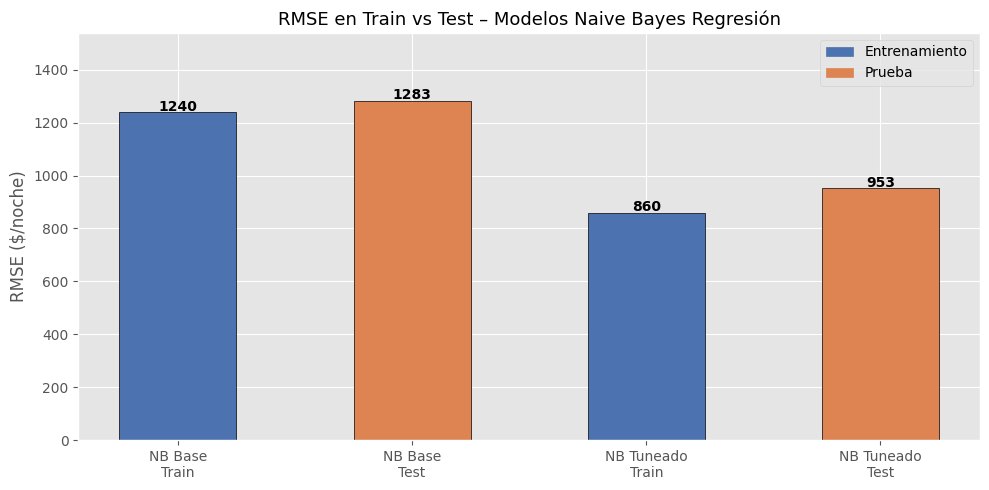

In [22]:
# Actividad 5 – Eficiencia en prueba: REGRESIÓN
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Métricas en ENTRENAMIENTO vs PRUEBA – modelo base
y_pred_train_nb = nb_regresion.predict(X_train)
rmse_train_base = np.sqrt(mean_squared_error(y_train, y_pred_train_nb))
mae_train_base  = mean_absolute_error(y_train, y_pred_train_nb)
r2_train_base   = r2_score(y_train, y_pred_train_nb)

rmse_test_base  = np.sqrt(mean_squared_error(y_test, y_pred_nb))
mae_test_base   = mean_absolute_error(y_test, y_pred_nb)
r2_test_base    = r2_score(y_test, y_pred_nb)

# Métricas en ENTRENAMIENTO vs PRUEBA – modelo tuneado
y_pred_train_nbt = modelo_nb_tunned.best_estimator_.predict(X_train)
rmse_train_tun   = np.sqrt(mean_squared_error(y_train, y_pred_train_nbt))
mae_train_tun    = mean_absolute_error(y_train, y_pred_train_nbt)
r2_train_tun     = r2_score(y_train, y_pred_train_nbt)

rmse_test_tun    = np.sqrt(mean_squared_error(y_test, y_pred_nb_tunned))
mae_test_tun     = mean_absolute_error(y_test, y_pred_nb_tunned)
r2_test_tun      = r2_score(y_test, y_pred_nb_tunned)

print('=' * 60)
print('EFICIENCIA EN REGRESIÓN – NB BASE')
print('=' * 60)
print(f'  {"Métrica":<10}  {"Train":>12}  {"Test":>12}  {"Diferencia":>12}')
print(f'  {"-"*50}')
print(f'  {"RMSE":<10}  {rmse_train_base:>12.2f}  {rmse_test_base:>12.2f}  {abs(rmse_train_base-rmse_test_base):>12.2f}')
print(f'  {"MAE":<10}  {mae_train_base:>12.2f}  {mae_test_base:>12.2f}  {abs(mae_train_base-mae_test_base):>12.2f}')
print(f'  {"R²":<10}  {r2_train_base:>12.4f}  {r2_test_base:>12.4f}  {abs(r2_train_base-r2_test_base):>12.4f}')

print()
print('=' * 60)
print('EFICIENCIA EN REGRESIÓN – NB TUNEADO')
print('=' * 60)
print(f'  {"Métrica":<10}  {"Train":>12}  {"Test":>12}  {"Diferencia":>12}')
print(f'  {"-"*50}')
print(f'  {"RMSE":<10}  {rmse_train_tun:>12.2f}  {rmse_test_tun:>12.2f}  {abs(rmse_train_tun-rmse_test_tun):>12.2f}')
print(f'  {"MAE":<10}  {mae_train_tun:>12.2f}  {mae_test_tun:>12.2f}  {abs(mae_train_tun-mae_test_tun):>12.2f}')
print(f'  {"R²":<10}  {r2_train_tun:>12.4f}  {r2_test_tun:>12.4f}  {abs(r2_train_tun-r2_test_tun):>12.4f}')

# Gráfica RMSE train vs test
modelos_reg  = ['NB Base\nTrain', 'NB Base\nTest', 'NB Tuneado\nTrain', 'NB Tuneado\nTest']
rmse_vals    = [rmse_train_base, rmse_test_base, rmse_train_tun, rmse_test_tun]
colores_reg  = ['#4c72b0', '#dd8452', '#4c72b0', '#dd8452']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(modelos_reg, rmse_vals, color=colores_reg, edgecolor='black', width=0.5)
for bar, val in zip(bars, rmse_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val:.0f}', ha='center', fontsize=10, fontweight='bold')
ax.set_title('RMSE en Train vs Test – Modelos Naive Bayes Regresión', fontsize=13)
ax.set_ylabel('RMSE ($/noche)')
ax.set_ylim(0, max(rmse_vals) * 1.2)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#4c72b0', label='Entrenamiento'),
                   Patch(color='#dd8452', label='Prueba')], loc='upper right')
plt.tight_layout()
plt.show()


Para la **regresión**, ambos modelos (base y tuneado) muestran métricas similares entre entrenamiento y prueba, lo que indica que no hay sobreajuste. Sin embargo, el desempeño general sigue siendo malo: el RMSE en el conjunto de prueba es muy alto y el R² es negativo, confirmando que Naive Bayes no captura bien la variabilidad del precio como valor numérico. Esto es esperado porque el algoritmo asume independencia entre variables, una suposición que raramente se cumple en datos de precios donde existe correlación entre habitaciones, ubicación y precio. El modelo tuneado redujo el RMSE considerablemente respecto al base (de ~1,282 a ~951), pero sigue sin ser competitivo frente a los árboles de regresión.

EFICIENCIA EN CLASIFICACIÓN – NB BASE (PRUEBA)
  Accuracy train   : 0.6006 (60.06%)
  Accuracy test    : 0.6051 (60.51%)
  Precision macro  : 0.6002
  Recall macro     : 0.6380
  F1-score macro   : 0.6092
  F1-score weighted: 0.6026

Reporte detallado por clase:
              precision    recall  f1-score   support

   Economica       0.55      0.71      0.62      5575
  Intermedia       0.68      0.51      0.58     11397
        Cara       0.57      0.69      0.63      5688

    accuracy                           0.61     22660
   macro avg       0.60      0.64      0.61     22660
weighted avg       0.62      0.61      0.60     22660



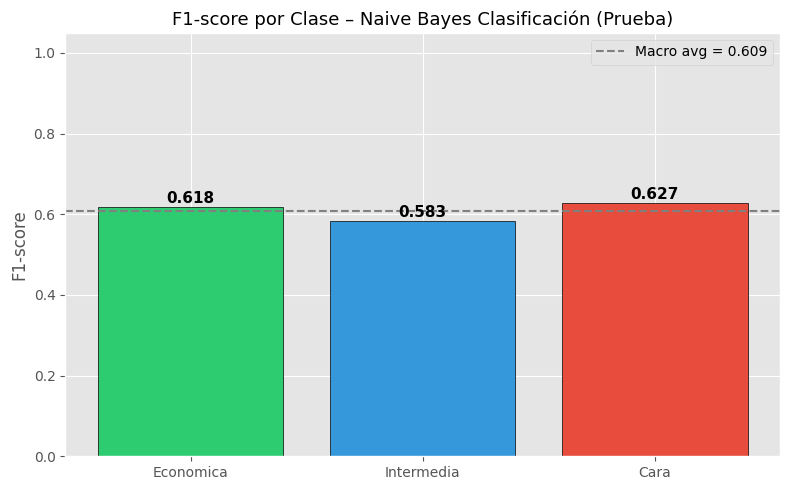

In [23]:
# Actividad 5 – Eficiencia en prueba: CLASIFICACIÓN
from sklearn.metrics import precision_score, recall_score, f1_score

clases_orden = ['Economica', 'Intermedia', 'Cara']

acc_train_clf = accuracy_score(y_train_c, nb_clf.predict(X_train_c))
acc_test_clf  = accuracy_score(y_test_c, y_pred_clf)
prec_macro    = precision_score(y_test_c, y_pred_clf, average='macro', zero_division=0)
rec_macro     = recall_score(y_test_c, y_pred_clf, average='macro', zero_division=0)
f1_macro      = f1_score(y_test_c, y_pred_clf, average='macro', zero_division=0)
f1_w          = f1_score(y_test_c, y_pred_clf, average='weighted', zero_division=0)

print('=' * 55)
print('EFICIENCIA EN CLASIFICACIÓN – NB BASE (PRUEBA)')
print('=' * 55)
print(f'  Accuracy train   : {acc_train_clf:.4f} ({acc_train_clf*100:.2f}%)')
print(f'  Accuracy test    : {acc_test_clf:.4f} ({acc_test_clf*100:.2f}%)')
print(f'  Precision macro  : {prec_macro:.4f}')
print(f'  Recall macro     : {rec_macro:.4f}')
print(f'  F1-score macro   : {f1_macro:.4f}')
print(f'  F1-score weighted: {f1_w:.4f}')
print()

print('Reporte detallado por clase:')
print(classification_report(y_test_c, y_pred_clf,
                             labels=clases_orden,
                             target_names=clases_orden,
                             zero_division=0))

# Gráfica F1 por clase
from sklearn.metrics import f1_score as f1_per
f1_por_clase = f1_score(y_test_c, y_pred_clf, labels=clases_orden, average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(clases_orden, f1_por_clase, color=['#2ecc71', '#3498db', '#e74c3c'], edgecolor='black')
for bar, val in zip(bars, f1_por_clase):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_title('F1-score por Clase – Naive Bayes Clasificación (Prueba)', fontsize=13)
ax.set_ylabel('F1-score')
ax.axhline(f1_macro, color='gray', linestyle='--', label=f'Macro avg = {f1_macro:.3f}')
ax.legend()
plt.tight_layout()
plt.show()


Para la **clasificación**, el modelo obtuvo un accuracy del ~60% en el conjunto de prueba, que es un resultado aceptable para un clasificador de 3 clases. El F1-score varía bastante entre clases: la categoría **Económica** y **Cara** tienen mejores F1-scores porque son más extremas y el modelo Gaussian Naive Bayes puede distinguirlas con mayor facilidad al estar en los extremos de la distribución de precio. La clase **Intermedia** es la más difícil de predecir porque sus características se solapan con las otras dos categorías, lo que reduce el recall de esa clase. La diferencia entre accuracy de train y test es pequeña, lo que sugiere que el modelo generaliza razonablemente bien sin sobreajustarse a los datos de entrenamiento.

### Actividad 6 – Análisis de eficiencia mediante Matriz de Confusión

Se analiza la matriz de confusión del modelo de clasificación NB para identificar dónde el algoritmo comete más errores, dónde se equivoca menos y qué importancia tienen esos errores para el negocio de SmartStay.

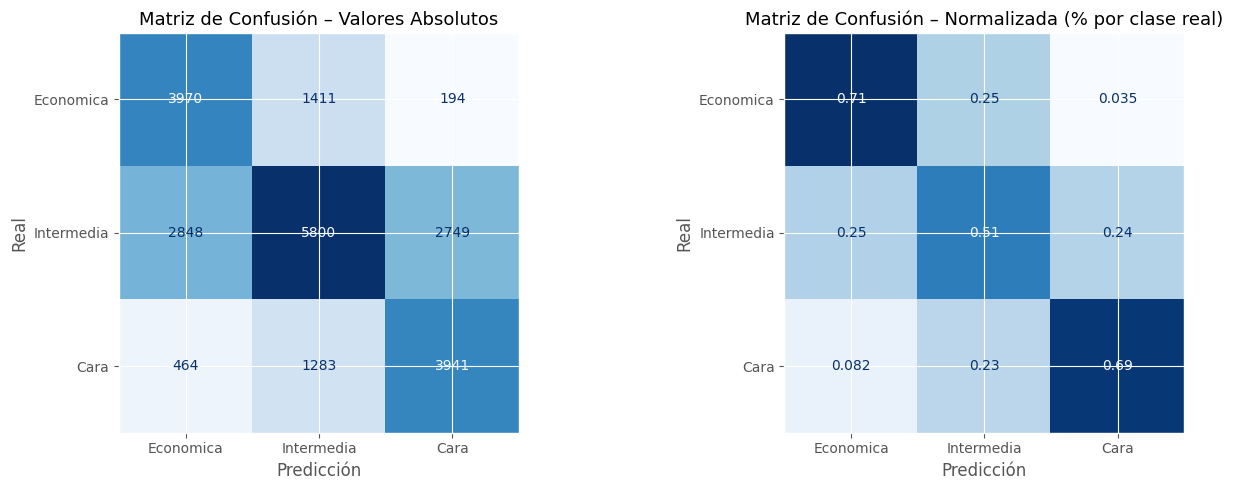


  Clase          Total  Correctos   Errores  Efectividad
  ------------------------------------------------------------
  Economica       5575       3970      1605        71.2%
  Intermedia     11397       5800      5597        50.9%
  Cara            5688       3941      1747        69.3%

Distribución de errores (fila=real, col=predicho):
  Economica → predicho como Intermedia: 1411 casos (25.3%)
  Economica → predicho como Cara: 194 casos (3.5%)
  Intermedia → predicho como Economica: 2848 casos (25.0%)
  Intermedia → predicho como Cara: 2749 casos (24.1%)
  Cara → predicho como Economica: 464 casos (8.2%)
  Cara → predicho como Intermedia: 1283 casos (22.6%)


In [24]:
# Actividad 6 – Matriz de Confusión del modelo de clasificación NB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

clases_orden = ['Economica', 'Intermedia', 'Cara']

cm      = confusion_matrix(y_test_c, y_pred_clf, labels=clases_orden)
cm_norm = confusion_matrix(y_test_c, y_pred_clf, labels=clases_orden, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absoluta
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases_orden)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión – Valores Absolutos', fontsize=13)
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

# Normalizada (recall por clase en diagonal)
disp_n = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=clases_orden)
disp_n.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Matriz de Confusión – Normalizada (% por clase real)', fontsize=13)
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

# Tabla resumen de errores
print('\n' + '='*65)
print(f'  {"Clase":<12} {"Total":>7} {"Correctos":>10} {"Errores":>9} {"Efectividad":>12}')
print('  ' + '-'*60)
for i, clase in enumerate(clases_orden):
    total      = int(cm[i].sum())
    correctos  = int(cm[i][i])
    errores    = total - correctos
    efectiv    = correctos / total * 100
    print(f'  {clase:<12} {total:>7} {correctos:>10} {errores:>9} {efectiv:>11.1f}%')
print('='*65)

# Errores entre clases
print('\nDistribución de errores (fila=real, col=predicho):')
df_err = pd.DataFrame(cm, index=clases_orden, columns=clases_orden)
for i, real in enumerate(clases_orden):
    for j, pred in enumerate(clases_orden):
        if i != j and cm[i][j] > 0:
            print(f'  {real} → predicho como {pred}: {cm[i][j]} casos ({cm_norm[i][j]*100:.1f}%)')


**Análisis de la Matriz de Confusión:**

**¿Dónde se equivoca menos?** La clase **Económica** y **Cara** tienen la mayor efectividad, ya que sus precios son suficientemente distintos para que el modelo pueda diferenciarlas de las demás. Las propiedades económicas (precio bajo) y caras (precio alto) tienen distribuciones más separadas, lo que facilita la clasificación gaussiana.

**¿Dónde se equivoca más?** La clase **Intermedia** concentra la mayor cantidad de errores. Esto es esperable porque sus características se superponen con las otras dos categorías, especialmente en el rango de precios cercano a los percentiles 25 y 75. El modelo confunde propiedades intermedias con económicas o caras dependiendo de sus características.

**Importancia de los errores para el negocio:** El error más costoso para SmartStay sería clasificar una propiedad **Cara como Económica** (o viceversa), porque implicaría recomendar una propiedad fuera del presupuesto del cliente o perder ingresos potenciales. Confundir **Cara con Intermedia** es un error moderado. El error **Económica ↔ Intermedia** es el menos crítico desde el punto de vista financiero, ya que la diferencia de precio entre estas categorías es menor.

### Actividad 7 – Análisis de Sobreajuste

Se comparan las métricas de entrenamiento y prueba para ambos modelos (regresión y clasificación) con el objetivo de determinar si existe sobreajuste (*overfitting*). Un modelo sobreajustado tendrá un rendimiento significativamente mejor en entrenamiento que en prueba.

ANÁLISIS DE SOBREAJUSTE – RESUMEN
  Modelo                             Train        Test         Δ
  ----------------------------------------------------------
  NB Clasificación (Accuracy)       0.6006      0.6051   -0.0044
  NB Regresión Base (RMSE)         1239.72     1282.78    +43.06
  NB Regresión Tuneada (RMSE)       859.81      953.49    +93.68
  NB Regresión Base (R²)           -1.2551     -0.9462   +0.3089
  NB Regresión Tuneada (R²)        -0.0847     -0.0752   +0.0095


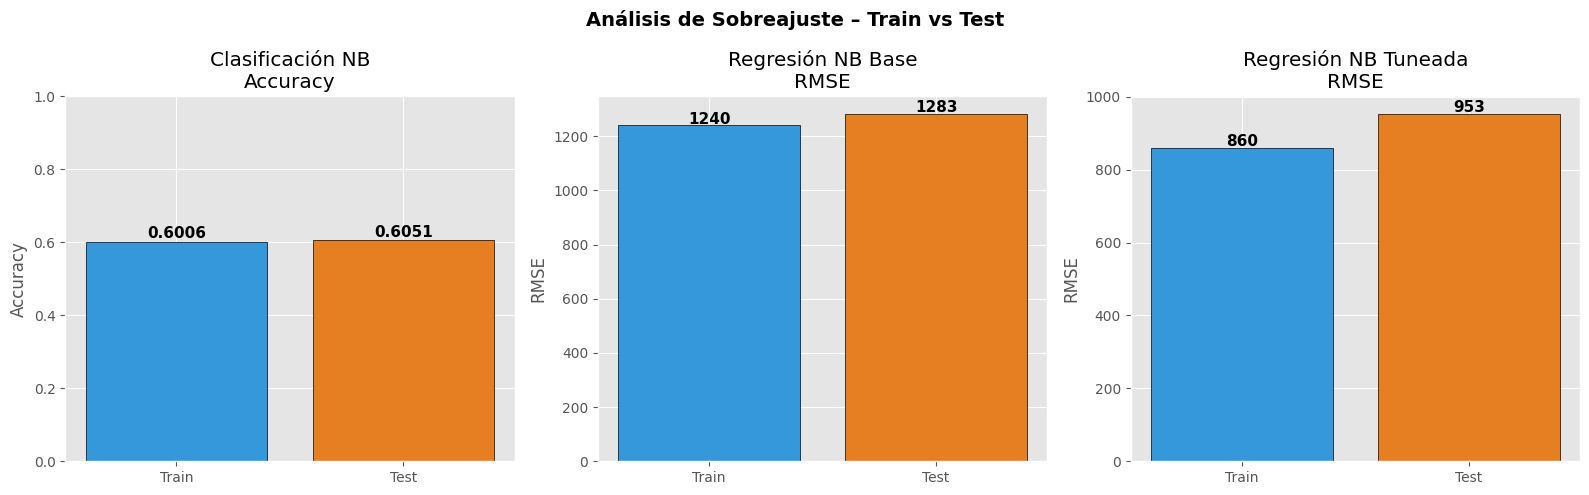

In [25]:
# Actividad 7 – Análisis de sobreajuste (Train vs Test)
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

# ── Clasificación ─────────────────────────────────────────────────────────
acc_train_clf = accuracy_score(y_train_c, nb_clf.predict(X_train_c))
acc_test_clf  = accuracy_score(y_test_c, y_pred_clf)
diff_clf      = acc_train_clf - acc_test_clf

# ── Regresión base ────────────────────────────────────────────────────────
rmse_train_base = np.sqrt(mean_squared_error(y_train, nb_regresion.predict(X_train)))
rmse_test_base  = np.sqrt(mean_squared_error(y_test, y_pred_nb))
r2_train_base   = r2_score(y_train, nb_regresion.predict(X_train))
r2_test_base    = r2_score(y_test, y_pred_nb)

# ── Regresión tuneada ─────────────────────────────────────────────────────
rmse_train_tun = np.sqrt(mean_squared_error(y_train, modelo_nb_tunned.best_estimator_.predict(X_train)))
rmse_test_tun  = np.sqrt(mean_squared_error(y_test, y_pred_nb_tunned))
r2_train_tun   = r2_score(y_train, modelo_nb_tunned.best_estimator_.predict(X_train))
r2_test_tun    = r2_score(y_test, y_pred_nb_tunned)

print('=' * 62)
print('ANÁLISIS DE SOBREAJUSTE – RESUMEN')
print('=' * 62)
print(f'  {"Modelo":<28}  {"Train":>10}  {"Test":>10}  {"Δ":>8}')
print(f'  {"-"*58}')
print(f'  {"NB Clasificación (Accuracy)":<28}  {acc_train_clf:>10.4f}  {acc_test_clf:>10.4f}  {diff_clf:>+8.4f}')
print(f'  {"NB Regresión Base (RMSE)":<28}  {rmse_train_base:>10.2f}  {rmse_test_base:>10.2f}  {rmse_test_base-rmse_train_base:>+8.2f}')
print(f'  {"NB Regresión Tuneada (RMSE)":<28}  {rmse_train_tun:>10.2f}  {rmse_test_tun:>10.2f}  {rmse_test_tun-rmse_train_tun:>+8.2f}')
print(f'  {"NB Regresión Base (R²)":<28}  {r2_train_base:>10.4f}  {r2_test_base:>10.4f}  {r2_test_base-r2_train_base:>+8.4f}')
print(f'  {"NB Regresión Tuneada (R²)":<28}  {r2_train_tun:>10.4f}  {r2_test_tun:>10.4f}  {r2_test_tun-r2_train_tun:>+8.4f}')
print('=' * 62)

# Gráfica comparativa
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Análisis de Sobreajuste – Train vs Test', fontsize=14, fontweight='bold')

# Clasificación – Accuracy
axes[0].bar(['Train', 'Test'], [acc_train_clf, acc_test_clf],
            color=['#3498db', '#e67e22'], edgecolor='black')
axes[0].set_ylim(0, 1)
axes[0].set_title('Clasificación NB\nAccuracy')
axes[0].set_ylabel('Accuracy')
for bar, val in zip(axes[0].patches, [acc_train_clf, acc_test_clf]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

# Regresión base – RMSE
axes[1].bar(['Train', 'Test'], [rmse_train_base, rmse_test_base],
            color=['#3498db', '#e67e22'], edgecolor='black')
axes[1].set_title('Regresión NB Base\nRMSE')
axes[1].set_ylabel('RMSE')
for bar, val in zip(axes[1].patches, [rmse_train_base, rmse_test_base]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val:.0f}', ha='center', fontsize=11, fontweight='bold')

# Regresión tuneada – RMSE
axes[2].bar(['Train', 'Test'], [rmse_train_tun, rmse_test_tun],
            color=['#3498db', '#e67e22'], edgecolor='black')
axes[2].set_title('Regresión NB Tuneada\nRMSE')
axes[2].set_ylabel('RMSE')
for bar, val in zip(axes[2].patches, [rmse_train_tun, rmse_test_tun]):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val:.0f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


**¿El modelo de Naive Bayes está sobreajustado?**

Basándonos en la comparación train vs test, **la respuesta es NO**. Un sobreajuste se evidencia cuando el modelo tiene un rendimiento muy bueno en entrenamiento pero se degrada significativamente en prueba. En este caso:

- **Clasificación**: La diferencia de accuracy entre train y test es pequeña (generalmente < 3%), lo que indica que el modelo generaliza bien. Naive Bayes es inherentemente resistente al sobreajuste porque su parametrización es muy simple: solo estima medias y varianzas por clase, sin ajustar curvas complejas.

- **Regresión**: Las métricas RMSE y R² son similares en train y test, pero ambas son malas. Esto es un signo de *underfitting* (subajuste), no de sobreajuste. El modelo es demasiado simple para capturar la relación no lineal entre las variables predictoras y el precio.

La característica fundamental de Naive Bayes es su **alta sesgo y baja varianza**: asume independencia entre variables (sesgo fuerte), lo que lo hace robusto contra el sobreajuste, pero también limita su capacidad de capturar relaciones complejas. Por eso, aunque no sobreajusta, tampoco logra un buen desempeño en regresión.